In [1]:
import sys
import os

# Dodanie katalogu głównego repo do ścieżki
sys.path.append(os.path.abspath(".."))

import numpy as np
from pipeline.model_core import dimensional_to_dimensionless, homogeneous_state
from pipeline.turing_instability import turing_analysis
from pipeline.pattern_visualization import simulate_patterns, plot_patterns

In [2]:
# parametry pełnowymiarowe
A  = 3
L  = 5
R  = 1
DW = 20
DN = 0.2
J  = 10
M  = 4

# rozmiar domeny - kwadratu i ilość punktów z niego pobranych
Lx = 10
N = 100

# konwersja
a, m, d1, d2 = dimensional_to_dimensionless(A, L, R, DW, J, M, DN, Lx)

# Sprawwdzenie wartości
print("a, m, d1, d2 =", a, m, d1, d2)
u_star, v_star = homogeneous_state(a, m)
print(f"stan jednorodny = ({u_star:.6f}, {v_star:.6f})")

res = turing_analysis(a, m, d1, d2, k_min=0, k_max=20, n_k=4000)
print("band =", res["band"])
print("max lambda =", res["lambda"].max())

a, m, d1, d2 = 2.6832815729997477 0.8 0.04 0.0004
stan jednorodny = (0.264608, 3.023342)
band = {'k_min': np.float64(16.644161040260066), 'k_max': np.float64(20.0), 'k_dom': np.float64(20.0)}
max lambda = 0.08228260089961081


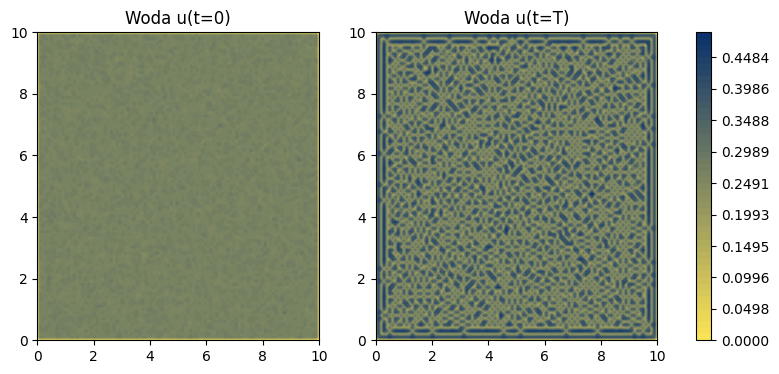

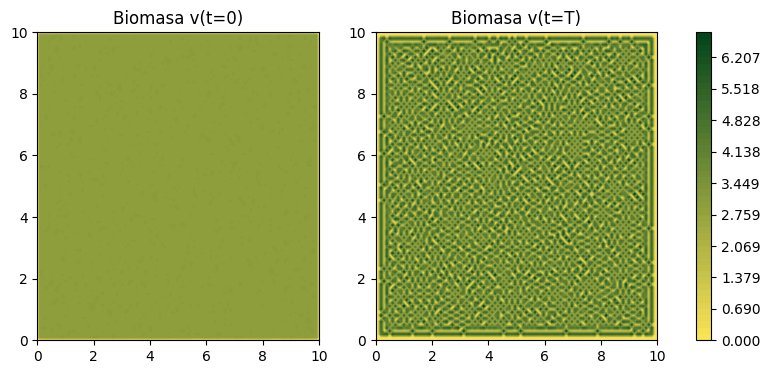

In [3]:
# Rysowanie wzorow na powyższych parametrach
wynik = simulate_patterns(a, m, d1, d2, Lx, Lx, N, N, T = 8000)
plot_patterns(wynik, wykres = "uv")

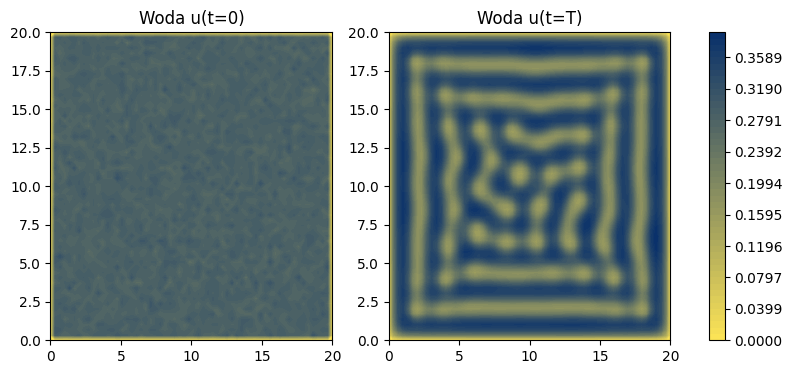

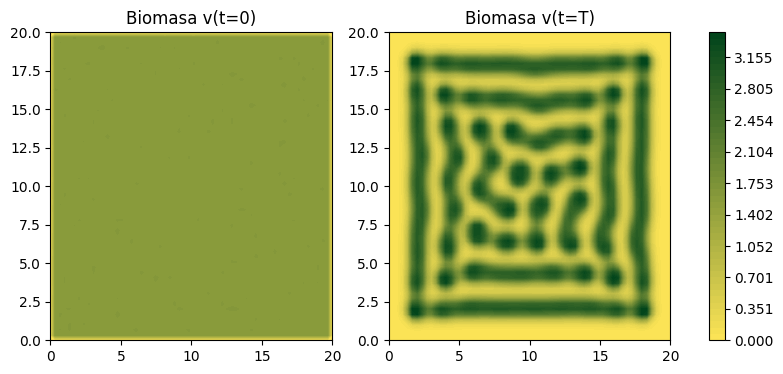

In [6]:
# Rysowanie wzorów dla parametrów z pracy Klausmeiera i wcześniejszego wykresu bifurkacji
# dla np L, N = 20, 60, T=8000
a, m, d1, d2 = 1, 0.45, 1, 0.02
L, N = 20, 60

wynik = simulate_patterns(a, m, d1, d2, L, L, N, N, T=8000)
plot_patterns(wynik, wykres="uv")